### **MACHINE LEARNING**

**Lab Experiment 5 : Linear Regression through Gradient Descent**

1. Download and load the Student Performance dataset.

In [10]:
! pip install ucimlrepo

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:

# fetch dataset 
student_performance = fetch_ucirepo(id=320) 
  
# data (as pandas dataframes) 
X = student_performance.data.features 
y = student_performance.data.targets["G3"]
  
# metadata 
print(student_performance.metadata) 
  
# variable information 
print(student_performance.variables) 


{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

In [33]:
print("First 5 Rows")
print(X.head())

print("\nDataset Shape:", X.shape)

First 5 Rows
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  higher internet  romantic  famrel  freetime goout Dalc Walc health absences  
0    yes       no        no       4         3     4    1    1      3        4  
1    yes      yes        no       5         3     3    1    1      3        2  
2    yes      yes        no       4         3     2    2    3      3        6  
3    yes      yes       yes       3         2     2    1    1      5        0  
4    yes       no        no       4         3     2    1    2      5        0  

[5 rows x 30 column

2. Perform data preprocessing, including handling missing values (if any), encoding categorical variables, and feature scaling.


In [34]:
print("Missing Values in Features")
print(X.isnull().sum())
print("\nTotal Missing Values")
print(X.isnull().sum().sum())

Missing Values in Features
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
dtype: int64

Total Missing Values
0


This checks whether the dataset contains any missing values. Since there is no missing values, no preprocessing is needed.

In [35]:
print(X.dtypes)

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
dtype: object


In [36]:
X = pd.get_dummies(X, drop_first=True)
print(X.head())

   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         0       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...            False           False          False        True   

   paid_yes  activities_yes  nursery_yes  higher_yes  internet

ML algorithms work only with numerical values so I am using get_dummies() which converts categorical columns into numeric columns.

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Feature scaling makes sure that all features are on the same scale which will helps to make the Gradient Descent converge faster.

3. Select appropriate input features and the target variable.



In [38]:
print("Input Features")
print(X.columns)
print("\nTarget Variable")
print(y.head())

Input Features
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'school_MS',
       'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health',
       'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health',
       'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home',
       'reason_other', 'reason_reputation', 'guardian_mother',
       'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes',
       'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes',
       'romantic_yes'],
      dtype='object')

Target Variable
0    11
1    11
2    12
3    14
4    13
Name: G3, dtype: int64


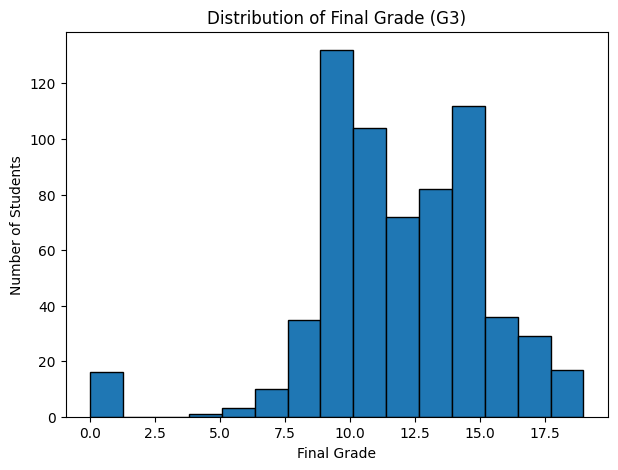

In [39]:
plt.figure(figsize=(7,5))

plt.hist(y, bins=15, edgecolor='black')

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

4. Split the dataset into training and testing sets.

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 519
Testing Samples : 130


In [41]:
print(X_train.shape)
print(y_train.shape)

(519, 39)
(519,)


80 % is used for training and 20% is used for testing data

5. Implement Linear Regression using the Gradient Descent algorithm.


In [42]:
import numpy as np
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):
    m, n = X.shape
    weights = np.zeros(n)
    bias = 0
    losses = []
    for i in range(iterations):
        y_pred = np.dot(X, weights) + bias
        error = y_pred - y
        loss = (1/(2*m)) * np.sum(error**2)
        losses.append(loss)
        dw = (1/m) * np.dot(X.T, error)
        db = (1/m) * np.sum(error)
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db
    return weights, bias, losses

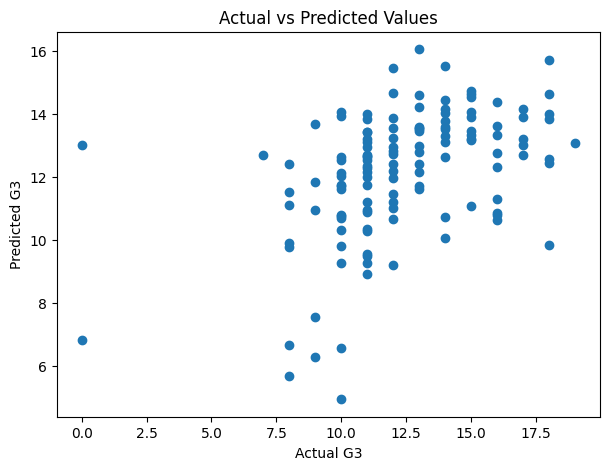

In [49]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")

plt.title("Actual vs Predicted Values")

plt.show()

6. Experiment with different learning rates and observe their effect on model convergence.


7. Plot the loss (cost) versus the number of iterations.


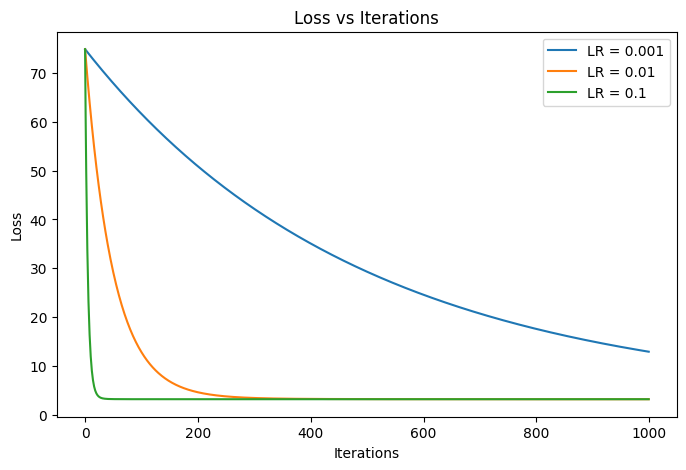

In [43]:
import matplotlib.pyplot as plt

learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(8,5))

for lr in learning_rates:

    w, b, losses = gradient_descent(
        X_train,
        y_train.values,
        learning_rate=lr,
        iterations=1000
    )

    plt.plot(losses, label=f"LR = {lr}")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")
plt.legend()
plt.show()

Interpretation:


The graph shows that the loss decreases as the number of iterations increases which means the model is learning and improving its predictions.

* Learning Rate=0.001 (Blue) : The loss decreases slowly. The model learns slowly and takes more time to converge.

* Learning Rate=0.01 (Orange) : The loss decreases faster than 0.001. The model learns well and converges smoothly.

* Learning Rate=0.1 (Green) : The loss decreases very quickly and reaches the minimum in fewer iterations. The model converges the fastest.

Final Conclusion:

Among the three learning rates, 0.1 converges the fastest, 0.01 also performs well, and 0.001 is the slowest. The graph shows that Gradient Descent successfully reduces the loss and improves the model.

8. Evaluate the trained model using: <br>
Mean Absolute Error (MAE)<br>
Mean Squared Error (MSE)<br>
Root Mean Squared Error (RMSE)<br>
R² Score


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 2.1563808259156168
Mean Squared Error (MSE): 8.18977338938655
Root Mean Squared Error (RMSE): 2.861778011898643
R² Score: 0.160171049970676


Mean Absolute Error (MAE): 2.1564 <br>
The predicted grades are about 2 marks different from the actual grades on average. <br>

Mean Squared Error (MSE): 8.1898 <br>
Interpretation: The model has some prediction errors, but they are not very large. <br>

Root Mean Squared Error (RMSE): 2.8618 <br>
Interpretation: The model's predictions are about 3 marks away from the actual grades on average. <br>

R² Score: 0.1602<br>
Interpretation: The model predicts the student grades, but its accuracy is low and it can be improved.

9. Interpret the results and comment on the convergence behavior and prediction performance of the model.

Convergence Behaviour:
    
With a learning rate of 0.001, the loss decreases slowly, so the model takes more iterations to converge.
With a learning rate of 0.01, the loss decreases smoothly and reaches convergence efficiently.
With a learning rate of 0.1, the model converges faster but may overshoot the minimum or oscillate if the rate is too high.

Prediction Performance:
    
A low MAE indicates that the average prediction error is small.
A low MSE and RMSE indicate that the predicted values are close to the actual values.
An R² Score close to 1 shows that the model explains most of the variance in student performance, indicating good predictive accuracy.